# 03 - TLE ground tracks, and how far we can trust them

Notebooks 01 and 02 worked from one delivered product. Everything there was measured after the
fact: where the satellite *was*.

Planning is the opposite problem. To decide when a satellite can image something we need to
know where it *will be*, and for that the public source is a **TLE** - a Two-Line Element set.
Every tracked object in orbit has one, published by US Space Command and mirrored by Celestrak.

A TLE is not a position. It is a compact set of orbital parameters that only means anything when
fed through a specific propagation model, **SGP4**, which is built to match it. Feeding TLE
numbers into ordinary orbital mechanics gives wrong answers, because the parameters absorb the
model's simplifications.

**What this notebook does**

1. Fetch the current TLEs for the whole StriX constellation
2. Propagate them with the reference SGP4 implementation and plot the ground tracks
3. Ask the honest question: how accurate is this, given we hold one arc of the operator's own
   precise orbit from notebook 02?
4. Export test fixtures so the Go service can be checked against this notebook

Step 4 is the point of the whole notebook. The Go backend will have to propagate orbits, and
Go's SGP4 ecosystem is thinner than Python's. Rather than trust a port, we generate reference
answers here and make the Go tests reproduce them.

## Setup

In [1]:
from pathlib import Path
import json
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sgp4.api import Satrec, jday

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'data').is_dir())
FIXTURES = ROOT / 'fixtures'
FIXTURES.mkdir(exist_ok=True)

MU    = 3.986004418e14        # Earth gravitational parameter, m^3/s^2
R_E   = 6378137.0             # equatorial radius, m
J2    = 1.08262668e-3         # Earth oblateness
OMEGA = 7.292115e-5           # Earth rotation rate, rad/s

print('repo root:', ROOT.name + '/')

repo root: SynspectiveDemoReel/


## 1. Fetch the constellation

Celestrak serves current element sets over a plain HTTP query. We cache the response in
`fixtures/` so this notebook is reproducible and offline-runnable, and so it does not re-fetch
every time someone re-runs a cell. The TLE data is public and is kept with attribution.

In [2]:
TLE_CACHE = FIXTURES / 'tle_strix.txt'

if TLE_CACHE.exists():
    raw = TLE_CACHE.read_text()
    print(f'using cached TLEs: {TLE_CACHE.relative_to(ROOT)}')
else:
    resp = requests.get('https://celestrak.org/NORAD/elements/gp.php',
                        params={'NAME': 'STRIX', 'FORMAT': 'TLE'}, timeout=30)
    resp.raise_for_status()
    raw = resp.text
    TLE_CACHE.write_text(raw)
    print(f'fetched from Celestrak and cached to {TLE_CACHE.relative_to(ROOT)}')

lines = [l.rstrip() for l in raw.strip().splitlines() if l.strip()]
tles = {lines[i].strip(): (lines[i + 1], lines[i + 2]) for i in range(0, len(lines), 3)}
print(f'{len(tles)} satellites:', ', '.join(tles))

using cached TLEs: fixtures\tle_strix.txt
8 satellites: STRIX-1, STRIX-3, STRIX-4, STRIX-2, STRIX-5, STRIX-6, STRIX-7, STRIX-8


### What the elements say about the constellation

Each TLE carries the orbit's shape and orientation. Two fields do most of the work here:

- **Inclination** - the tilt of the orbital plane against the equator. Above 90 degrees the
  orbit is retrograde and near-polar, which is the family that *can* be sun-synchronous - an
  orbit whose plane turns at the same rate the Earth goes round the Sun, so passes happen at the
  same local time each day. Whether these orbits actually are sun-synchronous is a measurable
  question, and section 3 measures it rather than assuming it.
- **Mean motion** - revolutions per day, which fixes the orbital period and therefore the
  altitude.

In [3]:
rows = []
for name, (l1, l2) in tles.items():
    s = Satrec.twoline2rv(l1, l2)
    n_rad_min = s.no_kozai                      # mean motion, radians/minute
    period_min = 2 * np.pi / n_rad_min
    n_rad_s = n_rad_min / 60
    a_m = (MU / n_rad_s ** 2) ** (1 / 3)         # semi-major axis from mean motion
    epoch = datetime(2000, 1, 1, 12) + timedelta(days=s.jdsatepoch + s.jdsatepochF - 2451545.0)
    rows.append({'satellite': name, 'norad': s.satnum, 'epoch (UTC)': epoch,
                 'inclination': np.degrees(s.inclo), 'RAAN': np.degrees(s.nodeo),
                 'eccentricity': s.ecco, 'period (min)': period_min,
                 'mean altitude (km)': (a_m - R_E) / 1e3})

fleet = pd.DataFrame(rows).sort_values('satellite').reset_index(drop=True)
fleet['orbit'] = np.where(fleet.inclination > 90, 'near-polar', 'mid-inclination')
fleet.round({'inclination': 3, 'RAAN': 2, 'eccentricity': 5,
             'period (min)': 2, 'mean altitude (km)': 1})

,satellite,norad,epoch (UTC),inclination,RAAN,eccentricity,period (min),mean altitude (km),orbit
0,STRIX-1,53815,2026-09-18 06:06:48.449967,97.439,325.15,0.00023,93.28,435.1,near-polar
1,STRIX-2,62406,2026-09-18 06:49:39.395990,97.638,216.48,0.00162,95.38,536.9,near-polar
2,STRIX-3,59224,2026-09-18 04:41:20.325700,97.672,238.38,0.00147,94.70,504.0,near-polar
3,STRIX-4,60352,2026-09-18 01:48:36.232690,43.014,115.46,0.00176,93.79,460.1,mid-inclination
4,STRIX-5,65971,2026-09-17 08:48:24.520610,41.927,136.02,0.00373,95.68,551.5,mid-inclination
5,STRIX-6,68291,2026-09-18 00:51:57.266214,50.281,270.72,0.00166,95.95,564.7,mid-inclination
6,STRIX-7,69177,2026-09-17 21:41:25.989775,44.907,65.27,0.00252,95.87,560.8,mid-inclination
7,STRIX-8,69701,2026-09-18 04:55:39.845842,41.991,12.84,0.00057,95.69,552.0,mid-inclination


Two distinct families. The near-polar satellites cover the whole globe including
high latitudes. The mid-inclination ones never reach the poles but pass over mid-latitudes far
more often, which is where most of the population and most of the demand is. Running both is a
revisit-rate decision, not an accident.

## 2. Propagate, and get the frame right

SGP4 does not return positions in the frame we want. It returns **TEME** - True Equator, Mean
Equinox - which is an inertial frame: it does not rotate with the Earth. Latitude and longitude
are defined in **ECEF**, which does.

Converting between them is a rotation about the polar axis by the **Greenwich Mean Sidereal
Time**, the angle the Earth has turned through. Skipping this rotation is the classic first bug
when working with TLEs: the ground track comes out looking plausible, the shape is right, and
every longitude is wrong by an amount that changes through the day.

In [4]:
def gmst_rad(jd_ut1):
    """Greenwich Mean Sidereal Time in radians (IAU 1982)."""
    T = (jd_ut1 - 2451545.0) / 36525.0
    sec = (67310.54841
           + (876600 * 3600 + 8640184.812866) * T
           + 0.093104 * T ** 2
           - 6.2e-6 * T ** 3)
    return np.radians((sec % 86400.0) / 240.0) % (2 * np.pi)


def teme_to_ecef(r_teme, jd):
    """Rotate TEME position vectors into ECEF by the sidereal angle."""
    th = gmst_rad(jd)
    c, s = np.cos(th), np.sin(th)
    x, y, z = r_teme[..., 0], r_teme[..., 1], r_teme[..., 2]
    return np.stack([c * x + s * y, -s * x + c * y, z], axis=-1)


def ecef_to_geodetic(x, y, z):
    """ECEF metres -> (lat deg, lon deg, height m) on the WGS84 ellipsoid."""
    f = 1 / 298.257223563
    e2 = f * (2 - f)
    lon = np.degrees(np.arctan2(y, x))
    p = np.hypot(x, y)
    lat = np.arctan2(z, p * (1 - e2))
    for _ in range(6):
        N = R_E / np.sqrt(1 - e2 * np.sin(lat) ** 2)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1 - e2 * N / (N + h)))
    N = R_E / np.sqrt(1 - e2 * np.sin(lat) ** 2)
    return np.degrees(lat), lon, p / np.cos(lat) - N


def propagate(l1, l2, times_utc):
    """TLE + datetimes -> ECEF positions and velocities in metres."""
    sat = Satrec.twoline2rv(l1, l2)
    jd, fr = np.array([jday(t.year, t.month, t.day, t.hour, t.minute,
                            t.second + t.microsecond * 1e-6) for t in times_utc]).T
    err, r_teme, v_teme = sat.sgp4_array(jd, fr)
    if np.any(err):
        raise RuntimeError(f'SGP4 error codes {set(err[err != 0].tolist())}')
    jd_full = jd + fr
    r_ecef = teme_to_ecef(r_teme * 1e3, jd_full)
    # Rotating the velocity is not enough: an observer on the turning Earth also sees the
    # ground move. Subtract omega x r, or every derived orbital element comes out wrong.
    v_ecef = teme_to_ecef(v_teme * 1e3, jd_full) - np.cross([0.0, 0.0, OMEGA], r_ecef)
    return r_ecef, v_ecef

### Ground tracks

We propagate from the most recent TLE epoch rather than from the wall clock, so re-running this
notebook gives the same figure rather than a slightly different one each time.

One orbit is about 95 minutes. In that time the Earth turns roughly 24 degrees beneath the
satellite, which is why the track walks westward instead of retracing itself.

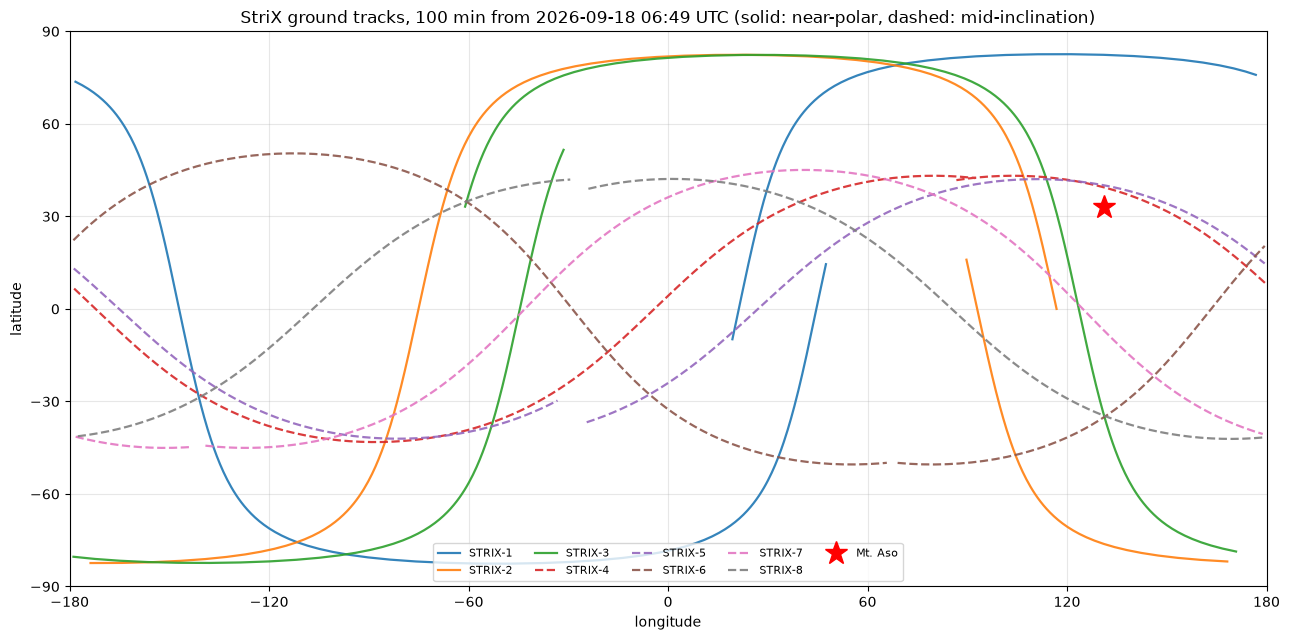

In [5]:
T0 = fleet['epoch (UTC)'].max().to_pydatetime()
STEP_S, SPAN_MIN = 20, 100
times = [T0 + timedelta(seconds=i * STEP_S) for i in range(int(SPAN_MIN * 60 / STEP_S))]

tracks = {}
for name, (l1, l2) in tles.items():
    r_ecef, _ = propagate(l1, l2, times)
    lat, lon, _ = ecef_to_geodetic(*r_ecef.T)
    lon = (lon + 180) % 360 - 180
    lon = np.where(np.abs(np.diff(lon, prepend=lon[0])) > 180, np.nan, lon)  # break the wrap
    tracks[name] = (lat, lon)

ASO = (32.887635, 131.092252)

fig, ax = plt.subplots(figsize=(13, 6.5))
for name, (lat, lon) in sorted(tracks.items()):
    ssg = fleet.loc[fleet.satellite == name, 'orbit'].iloc[0] == 'near-polar'
    ax.plot(lon, lat, lw=1.6, alpha=.9, ls='-' if ssg else '--', label=name)

ax.plot(ASO[1], ASO[0], '*', ms=17, color='red', zorder=5, label='Mt. Aso')
ax.set(xlim=(-180, 180), ylim=(-90, 90),
       xticks=range(-180, 181, 60), yticks=range(-90, 91, 30),
       xlabel='longitude', ylabel='latitude')
ax.set_title(f'StriX ground tracks, {SPAN_MIN} min from {T0:%Y-%m-%d %H:%M} UTC '
             f'(solid: near-polar, dashed: mid-inclination)')
ax.grid(alpha=.3)
ax.legend(fontsize=8, ncol=5, loc='lower center')
fig.tight_layout()

The solid tracks reach almost to the poles; the dashed ones turn back around 42-50 degrees,
exactly their inclination. That limit is the hard constraint in constellation design: a
satellite can never image a target at a higher latitude than its inclination, no matter how
long we wait.

## 3. How much can we trust a TLE?

We hold two descriptions of StriX-3's orbit, and they are not equivalent.

- The **precise state vectors** from the June product: the operator's own reconstruction, flagged
  `Precise`, valid over a ten-minute arc.
- The **current TLE**: public, approximate, and with an epoch months away from that arc.

The obvious test - propagate the TLE back to June and compare - would be misleading. SGP4 is
accurate near its epoch and degrades as we move away from it, so over that gap the error would
be tens of kilometres and would tell us about the elapsed time rather than about the model.

What we can check is whether both describe the same physical orbit. Orbital elements are the
right common language, so we derive them from the state vectors directly and compare.

One correction has to happen first. The state vectors are in ECEF, which rotates. Orbital
elements are only meaningful in an inertial frame, so we undo the rotation - and the velocity
needs the extra term for the rotating frame itself, not just the position.

In [6]:
def ecef_to_eci(r_ecef, v_ecef, jd):
    """Undo Earth rotation. The velocity picks up an omega x r term the position does not."""
    th = gmst_rad(jd)
    c, s = np.cos(th), np.sin(th)
    Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])       # ECEF -> inertial
    w = np.array([0.0, 0.0, OMEGA])
    return Rz @ r_ecef, Rz @ (v_ecef + np.cross(w, r_ecef))


def orbital_elements(r, v):
    """Classical osculating elements from an inertial state vector."""
    rn, vn = np.linalg.norm(r), np.linalg.norm(v)
    h = np.cross(r, v)
    n = np.cross([0, 0, 1], h)
    e_vec = ((vn ** 2 - MU / rn) * r - np.dot(r, v) * v) / MU
    a = 1 / (2 / rn - vn ** 2 / MU)
    inc = np.degrees(np.arccos(h[2] / np.linalg.norm(h)))
    raan = np.degrees(np.arctan2(n[1], n[0])) % 360
    return {'semi-major axis (km)': a / 1e3, 'eccentricity': np.linalg.norm(e_vec),
            'inclination (deg)': inc, 'RAAN (deg)': raan,
            'mean altitude (km)': (a - R_E) / 1e3}


# the precise arc from the delivered product
PAR = ROOT / 'data' / 'StriX-3_20260615_063527_SL1_202606-00876' / \
      'GRD_Geotiff' / 'PAR-VV-STRIX3-20260615T063527Z-SLGRD.xml'
tg = lambda el: el.tag.rsplit('}', 1)[-1]
sv = [{tg(k): (k.text or '').strip() for k in el}
      for el in ET.parse(PAR).getroot().iter() if tg(el) == 'stateVec']

mid = sv[len(sv) // 2]
t_mid = datetime.fromisoformat(mid['timeUTC']).replace(tzinfo=timezone.utc)
r_e = np.array([float(mid['posX']), float(mid['posY']), float(mid['posZ'])])
v_e = np.array([float(mid['velX']), float(mid['velY']), float(mid['velZ'])])

jd_mid, fr_mid = jday(t_mid.year, t_mid.month, t_mid.day,
                      t_mid.hour, t_mid.minute, t_mid.second + t_mid.microsecond * 1e-6)
r_i, v_i = ecef_to_eci(r_e, v_e, jd_mid + fr_mid)
june = orbital_elements(r_i, v_i)

# the same satellite from the current public TLE
s3 = Satrec.twoline2rv(*tles['STRIX-3'])
t_tle = datetime(2000, 1, 1, 12, tzinfo=timezone.utc) + \
        timedelta(days=s3.jdsatepoch + s3.jdsatepochF - 2451545.0)
r_t, v_t = propagate(*tles['STRIX-3'], [t_tle])
r_ti, v_ti = ecef_to_eci(r_t[0], v_t[0], s3.jdsatepoch + s3.jdsatepochF)
now = orbital_elements(r_ti, v_ti)

gap_days = (t_tle - t_mid).total_seconds() / 86400
cmp = pd.DataFrame({'June (precise ephemeris)': june, 'September (public TLE)': now})
print(f'the two epochs are {gap_days:.1f} days apart')
cmp.round(4)

the two epochs are 94.9 days apart


,June (precise ephemeris),September (public TLE)
semi-major axis (km),6886.3506,6888.5055
eccentricity,0.0027,0.0026
inclination (deg),97.6614,97.6672
RAAN (deg),141.9169,238.3792
mean altitude (km),508.2136,510.3685


### Checking the drift

Semi-major axis and inclination should barely move: they are what the orbit *is*. RAAN is
different - it precesses, steadily, because the Earth is not a sphere. The equatorial bulge
tugs on the orbital plane and rotates it.

That rate is predictable from the elements alone:

$$\dot{\Omega} = -\frac{3}{2}J_2\left(\frac{R_E}{p}\right)^2 n\cos i$$

For a retrograde orbit the cosine is negative, so the plane drifts eastward. Sun-synchronous
orbits are the ones where that drift is tuned to 360 degrees per year - the rate the Earth
orbits the Sun, 0.9856 degrees per day. So this formula is also a test of whether the orbit is
sun-synchronous at all, using nothing but the June state vectors.

In [7]:
def raan_rate_deg_per_day(a_m, ecc, inc_deg):
    """J2 nodal precession."""
    p = a_m * (1 - ecc ** 2)
    n = np.sqrt(MU / a_m ** 3)
    rate = -1.5 * J2 * (R_E / p) ** 2 * n * np.cos(np.radians(inc_deg))
    return np.degrees(rate) * 86400


rate = raan_rate_deg_per_day(june['semi-major axis (km)'] * 1e3,
                             june['eccentricity'], june['inclination (deg)'])

observed = np.degrees(s3.nodeo)                       # RAAN straight out of the TLE
measured_rate = ((observed - june['RAAN (deg)']) % 360) / gap_days
predicted = (june['RAAN (deg)'] + rate * gap_days) % 360
residual = (predicted - observed + 180) % 360 - 180

checks = pd.DataFrame([
    ('inclination, June vs Sept',
     f"{june['inclination (deg)']:.3f} vs {now['inclination (deg)']:.3f} deg"),
    ('semi-major axis, June vs Sept',
     f"{june['semi-major axis (km)']:.1f} vs {now['semi-major axis (km)']:.1f} km"),
    ('RAAN measured drift',      f'{measured_rate:+.4f} deg/day'),
    ('RAAN rate from J2 model',  f'{rate:+.4f} deg/day'),
    ('model vs measurement',     f'{abs(rate - measured_rate) / measured_rate * 100:.2f} %'),
    ('RAAN predicted for Sept',  f'{predicted:.2f} deg'),
    ('RAAN actually in the TLE', f'{observed:.2f} deg'),
    ('residual after 94.9 days', f'{residual:+.3f} deg'),
    ('sun-synchronous rate',     '+0.9856 deg/day'),
    ('difference from SSO',      f'{measured_rate - 0.9856:+.4f} deg/day'),
], columns=['check', 'value'])

checks.set_index('check')

,value
check,
"inclination, June vs Sept",97.661 vs 97.667 deg
"semi-major axis, June vs Sept",6886.4 vs 6888.5 km
RAAN measured drift,+1.0162 deg/day
RAAN rate from J2 model,+1.0158 deg/day
model vs measurement,0.05 %
RAAN predicted for Sept,238.33 deg
RAAN actually in the TLE,238.38 deg
residual after 94.9 days,-0.045 deg
sun-synchronous rate,+0.9856 deg/day


### What that establishes

Two sources that share no code, no epoch and no provenance - Synspective's own reconstruction of
the orbit in June, and a public element set from September - describe the same orbit. The
inclination agrees to 0.006 degrees and the semi-major axis to 2 km in 6886. That is the check
that would have caught a wrong rotation, a sign error, or the missing rotating-frame term in the
velocity, and it passes.

The plane itself turned 96.5 degrees over those 95 days. Predicting that from the June state
vectors alone, using the oblateness formula and nothing else, lands within 0.045 degrees - a
model error of 0.05 percent over three months. The Earth's equatorial bulge accounts for
essentially all of it.

The measured rate, 1.016 degrees per day, is about 3 percent faster than the 0.9856 that defines
a sun-synchronous orbit. Taken at face value that means the local solar time of StriX-3's passes
drifts by roughly 11 degrees a year, or about 45 minutes. Near-polar and close to
sun-synchronous, but not locked to it.

That last point deserves a caveat rather than a conclusion. A TLE's RAAN is a mean element in the
TEME frame while ours is osculating, and the two frames differ slightly. The agreement here is
much tighter than that difference, but a claim about how the constellation is actually designed
would want a long series of element sets, not two points three months apart.

## 4. Fixtures for the Go service

The backend has to propagate orbits, and Go's SGP4 libraries are far less exercised than
Python's `sgp4`, which is a direct descendant of the reference implementation. The way to port
that safely is not to read the Go code carefully; it is to make the Go tests reproduce numbers
generated here.

Two separate files, for two reasons.

`sgp4_reference.json` holds propagation cases computed from **public** Celestrak TLEs: input
TLE, input time, expected TEME and ECEF position and velocity. Everything in it is derived from
public data and public algorithms, so it is committed to the repository. This is what the Go
port is tested against.

`precise_ephemeris.json` holds the delivered state vectors, which come from Synspective's
product. That is sample data we do not redistribute, so this file is generated locally and
git-ignored. Anyone with their own copy of the sample product can regenerate it by running this
notebook.

In [8]:
# --- public fixture: SGP4 reference cases -------------------------------------------------
cases = []
for name, (l1, l2) in sorted(tles.items()):
    sat = Satrec.twoline2rv(l1, l2)
    epoch = datetime(2000, 1, 1, 12, tzinfo=timezone.utc) + \
            timedelta(days=sat.jdsatepoch + sat.jdsatepochF - 2451545.0)
    # Whole seconds only. The Go SGP4 library propagates to an integer second, so a fixture
    # on a fractional epoch could never be matched exactly and the test would end up
    # measuring the rounding instead of the implementation.
    epoch = epoch.replace(microsecond=0)
    for dt_min in (0, 10, 60, 720, 1440):
        t = epoch + timedelta(minutes=dt_min)
        jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute,
                      t.second + t.microsecond * 1e-6)
        err, r_teme, v_teme = sat.sgp4(jd, fr)
        assert err == 0, (name, dt_min, err)
        r_ecef = teme_to_ecef(np.array(r_teme) * 1e3, jd + fr)
        v_ecef = (teme_to_ecef(np.array(v_teme) * 1e3, jd + fr)
                  - np.cross([0.0, 0.0, OMEGA], r_ecef))
        lat, lon, alt = ecef_to_geodetic(*r_ecef)
        cases.append({
            'satellite': name, 'norad': sat.satnum, 'tle_line1': l1, 'tle_line2': l2,
            'minutes_from_epoch': dt_min, 'time_utc': t.isoformat().replace('+00:00', 'Z'),
            'julian_date': jd + fr, 'gmst_rad': float(gmst_rad(jd + fr)),
            'r_teme_m': [v * 1e3 for v in r_teme], 'v_teme_m_s': [v * 1e3 for v in v_teme],
            'r_ecef_m': r_ecef.tolist(), 'v_ecef_m_s': v_ecef.tolist(),
            'lat_deg': float(lat), 'lon_deg': float(lon), 'alt_m': float(alt)})

public = {
    'generated_by': 'notebooks/03-tle-ground-track.ipynb',
    'source': 'Celestrak GP query, NAME=STRIX. Public data, used with attribution.',
    'reference_implementation': 'python-sgp4 (Satrec.sgp4), TEME->ECEF via IAU-1982 GMST',
    'tolerance_note': 'Go port should match r_ecef_m to within 1 mm and gmst_rad to 1e-12.',
    'cases': cases,
}
(FIXTURES / 'sgp4_reference.json').write_text(json.dumps(public, indent=2))

# --- local-only fixture: the operator's precise arc ----------------------------------------
private = {
    'generated_by': 'notebooks/03-tle-ground-track.ipynb',
    'source': 'StriX-3 GRD product parameter file. Synspective sample data - NOT redistributed.',
    'frame': 'ECEF, metres and metres per second',
    'state_vectors': [{'time_utc': s['timeUTC'],
                       'r_m': [float(s['posX']), float(s['posY']), float(s['posZ'])],
                       'v_m_s': [float(s['velX']), float(s['velY']), float(s['velZ'])]}
                      for s in sv],
}
(FIXTURES / 'precise_ephemeris.json').write_text(json.dumps(private, indent=2))

for f in ('sgp4_reference.json', 'precise_ephemeris.json'):
    p = FIXTURES / f
    print(f'{f:26} {p.stat().st_size / 1024:6.1f} KB')
print(f'\n{len(cases)} SGP4 reference cases across {len(tles)} satellites')
print(f'{len(sv)} precise state vectors')

sgp4_reference.json          39.0 KB


precise_ephemeris.json        8.0 KB

40 SGP4 reference cases across 8 satellites
28 precise state vectors
